Kaggle competition - random forest

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,  cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [5]:
# Set data
train = pd.read_csv("data/train.csv")
features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]

When looking at the whole data with our features of interest I notice that this depth is of concern. I want to look at if there is a big effect of these 14 outliers at the end of the data. 

       CTDTEMP_ITS90           TA  Salinity_PSS78        Depth          DIC
count      14.000000    14.000000       14.000000    14.000000    14.000000
mean        1.714214  2427.292857       34.660286  3327.928571  2352.250000
std         0.620636    18.310546        0.055397   670.180741     4.697913
min         1.520000  2364.100000       34.470000  1000.000000  2348.300000
25%         1.542500  2430.750000       34.670000  3499.000000  2350.025000
50%         1.550000  2432.000000       34.680000  3500.000000  2350.700000
75%         1.560000  2432.925000       34.680000  3504.750000  2351.625000
max         3.870000  2437.100000       34.680000  3542.000000  2364.600000

Count: 14

DIC mean WITH outliers:    2117.76
DIC mean WITHOUT outliers: 2116.79


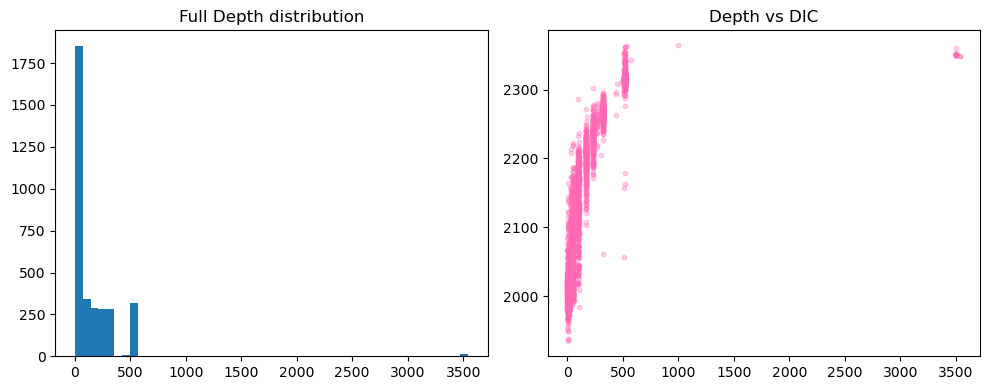

In [6]:
# Look at the outliers
depth_outliers = train[train["Depth"] > 600]
print(depth_outliers[features + ["DIC"]].describe())
print(f"\nCount: {len(depth_outliers)}")

# Compare DIC distribution with vs without
print(f"\nDIC mean WITH outliers:    {train['DIC'].mean():.2f}")
print(f"DIC mean WITHOUT outliers: {train[train['Depth'] <= 600]['DIC'].mean():.2f}")

# Plot depth distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(train["Depth"], bins=50, fill = 'dodgerblue')
plt.title("Full Depth distribution")

plt.subplot(1, 2, 2)
plt.scatter(train["Depth"], train["DIC"], alpha=0.3, s=10, c = 'hotpink')
plt.title("Depth vs DIC")
plt.tight_layout()
plt.show()

In [7]:
X = train[features]
y = train.DIC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [8]:
# Grid search
param_grid = {
    'n_estimators':      [100, 200],
    'max_features':      ['sqrt', 0.5],
    'max_depth':         [10, 20, None],
    'min_samples_leaf':  [1, 3, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

# Evaluate on local validation set
best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test)

print("Best params:", rf_grid.best_params_)
print(f"Val R²:   {r2_score(y_test, y_pred):.4f}")
print(f"Val RMSE: {mean_squared_error(y_test, y_pred, squared=False):.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Val R²:   0.9849
Val RMSE: 14.5626


In [9]:
# Train R² to check overfit gap
y_train_pred = best_rf.predict(X_train)
print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Val R²:   {r2_score(y_test, y_pred):.4f}")

# Feature importances
importances = pd.Series(best_rf.feature_importances_, index= features).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

Train R²: 0.9945
Val R²:   0.9849

Feature importances:
CTDTEMP_ITS90     0.498808
Salinity_PSS78    0.281666
Depth             0.180447
TA                0.039079
dtype: float64


In [43]:


features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]
X = train[features]
y = train["DIC"]

xgb_param_grid = {
    'n_estimators':   [200, 500],
    'learning_rate':  [0.05, 0.1],
    'max_depth':      [4, 6, 8],
    'subsample':      [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)

print("Best params:", xgb_grid.best_params_)
print(f"Val R²:   {r2_score(y_val, y_pred_xgb):.4f}")
print(f"Val RMSE: {mean_squared_error(y_val, y_pred_xgb, squared=False):.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Val R²:   0.9890
Val RMSE: 12.3171


In [27]:
# Overfit gap
y_train_pred_xgb = best_xgb.predict(X_train)
print(f"Train R²: {r2_score(y_train, y_train_pred_xgb):.4f}")
print(f"Val R²:   {r2_score(y_val, y_pred_xgb):.4f}")

# Can we squeeze more with higher n_estimators?
xgb_500 = XGBRegressor(**{**xgb_grid.best_params_, 'n_estimators': 500}, random_state=42, n_jobs=-1)
scores = cross_val_score(xgb_500, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"\nn_estimators=500 CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

Train R²: 0.9947
Val R²:   0.9890

n_estimators=500 CV R²: 0.9651 ± 0.0265


In [28]:
# Retrain best XGB on full training data
final_model = XGBRegressor(**xgb_grid.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X, y)

# Verify it looks sane
y_full_pred = final_model.predict(X)
print(f"Full train R²: {r2_score(y, y_full_pred):.4f}")

# Generate Kaggle submission
test = pd.read_csv("data/test.csv")
X_test_kaggle = test[features]

preds = final_model.predict(X_test_kaggle)

submission = pd.DataFrame({
    "id": test["id"],  # adjust column name if different
    "DIC": preds
})

submission.to_csv("submission.csv", index=False)
print(submission.head())
print(f"Shape: {submission.shape}")

Full train R²: 0.9943
   id          DIC
0   6  1998.495239
1   8  1986.928955
2  12  1985.573608
3  14  1982.370605
4  17  1987.867188
Shape: (848, 2)
